
# 01 — SFT Baseline: Qwen2-0.5B

This notebook runs a **small end-to-end supervised fine-tuning (SFT) experiment** using:

- `sshleifer/tiny-gpt2`
- `yahma/alpaca-cleaned`
- the project's own `SFTProcessor`, `SFTCollator`, `LMLoss`, and `Trainer`

The first goal is **implementation validation**, not producing a strong instruction-tuned model.

We deliberately use a small subset of the dataset so this can run on free Colab/Kaggle hardware.



## 0. Imports


In [ ]:
import math
import random
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM

from data.sft import SFTProcessor, SFTCollator
from objectives.lm import LMLoss
from trainers.trainer import Trainer

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


d:\Tech\PostTrain\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.7.1+cu118
CUDA available: True
Device: cuda


In [2]:
torch.cuda.empty_cache()

## 1. Load TinyGPT2

In [3]:
MODEL_NAME = "sshleifer/tiny-gpt2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)

print("Model loaded.")
print("Parameters:", sum(p.numel() for p in model.parameters()) / 1e6, "M")


Loading weights: 100%|██████████| 29/29 [00:00<00:00, 3712.79it/s]
[transformers] GPT2LMHeadModel LOAD REPORT from: sshleifer/tiny-gpt2
Key                                   | Status     |  | 
--------------------------------------+------------+--+-
transformer.h.{0, 1}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded.
Parameters: 0.102714 M


In [ ]:
# TinyGPT2 does not necessarily have a dedicated pad token.
# For this first experiment, using EOS as PAD is a common simple choice.

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

print("EOS token:", tokenizer.eos_token, tokenizer.eos_token_id)
print("PAD token:", tokenizer.pad_token, tokenizer.pad_token_id)


EOS token: <|endoftext|> 50256
PAD token: <|endoftext|> 50256


## 2. Load a small Alpaca subset

In [5]:
dataset = load_dataset("yahma/alpaca-cleaned", split="train")

# Small experiment first.
N_EXAMPLES = 500
dataset = dataset.select(range(min(N_EXAMPLES, len(dataset))))

print(dataset)
print(dataset[0])


Dataset({
    features: ['output', 'input', 'instruction'],
    num_rows: 500
})
{'output': '1. Eat a balanced and nutritious diet: Make sure your meals are inclusive of a variety of fruits and vegetables, lean protein, whole grains, and healthy fats. This helps to provide your body with the essential nutrients to function at its best and can help prevent chronic diseases.\n\n2. Engage in regular physical activity: Exercise is crucial for maintaining strong bones, muscles, and cardiovascular health. Aim for at least 150 minutes of moderate aerobic exercise or 75 minutes of vigorous exercise each week.\n\n3. Get enough sleep: Getting enough quality sleep is crucial for physical and mental well-being. It helps to regulate mood, improve cognitive function, and supports healthy growth and immune function. Aim for 7-9 hours of sleep each night.', 'input': '', 'instruction': 'Give three tips for staying healthy.'}



## 3. Convert Alpaca examples into prompt/response pairs

Our `SFTProcessor` currently expects:

```python
{
    "prompt": "...",
    "response": "..."
}
```

Alpaca gives us `instruction`, `input`, and `output`.

We will construct a simple prompt ourselves for this baseline. This intentionally avoids introducing chat-template complexity into the first experiment.


In [6]:

def alpaca_to_sft(example):
    instruction = example["instruction"].strip()
    extra_input = example["input"].strip()
    response = example["output"].strip()

    if extra_input:
        prompt = f"{instruction}\n\nInput:\n{extra_input}\n\nResponse:"
    else:
        prompt = f"{instruction}\n\nResponse:"

    return {
        "prompt": prompt,
        "response": response,
    }


sft_dataset = dataset.map(
    alpaca_to_sft,
    remove_columns=dataset.column_names,
)

print(sft_dataset[0])


{'prompt': 'Give three tips for staying healthy.\n\nResponse:', 'response': '1. Eat a balanced and nutritious diet: Make sure your meals are inclusive of a variety of fruits and vegetables, lean protein, whole grains, and healthy fats. This helps to provide your body with the essential nutrients to function at its best and can help prevent chronic diseases.\n\n2. Engage in regular physical activity: Exercise is crucial for maintaining strong bones, muscles, and cardiovascular health. Aim for at least 150 minutes of moderate aerobic exercise or 75 minutes of vigorous exercise each week.\n\n3. Get enough sleep: Getting enough quality sleep is crucial for physical and mental well-being. It helps to regulate mood, improve cognitive function, and supports healthy growth and immune function. Aim for 7-9 hours of sleep each night.'}


## 4. Build the SFT processor

In [7]:
processor = SFTProcessor(
    tokenizer=tokenizer,
    assistant_token_id=tokenizer.eos_token_id,
    ignore_index=-100,
)

In [8]:
processed_examples = [
    processor.process(example)
    for example in sft_dataset
]

print(processed_examples[0])
print("Sequence length:", len(processed_examples[0]["input_ids"]))


{'input_ids': tensor([23318,  1115,  9040,   329, 10589,  5448,    13,   198,   198, 31077,
           25, 50256,    16,    13, 27574,   257, 12974,   290, 48102,  5496,
           25,  6889,  1654,   534, 13840,   389, 19889,   286,   257,  4996,
          286, 15921,   290, 13701,    11, 10904,  7532,    11,  2187, 21824,
           11,   290,  5448, 27997,    13,   770,  5419,   284,  2148,   534,
         1767,   351,   262,  6393, 20901,   284,  2163,   379,   663,  1266,
          290,   460,  1037,  2948, 10726, 10040,    13,   198,   198,    17,
           13,  1985,   496,   287,  3218,  3518,  3842,    25, 32900,   318,
         8780,   329, 10941,  1913, 11945,    11, 12749,    11,   290, 21134,
         1535,    13, 36223,   329,   379,  1551,  6640,  2431,   286, 10768,
        43294,  5517,   393,  5441,  2431,   286, 31543,  5517,  1123,  1285,
           13,   198,   198,    18,    13,  3497,  1576,  3993,    25, 18067,
         1576,  3081,  3993,   318,  8780,   329, 


## 5. Collate examples into batches

We use the project's `SFTCollator` for right-padding.

The resulting tensors should have shape:

```text
input_ids       [B, T]
labels          [B, T]
attention_mask  [B, T]
```


In [9]:
from torch.utils.data import DataLoader

collator = SFTCollator(
    pad_token_id=tokenizer.pad_token_id,
    ignore_index=-100,
)

BATCH_SIZE = 4

dataloader = DataLoader(
    processed_examples,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collator,
)

batch = next(iter(dataloader))

for key, value in batch.items():
    print(key, value.shape, value.dtype)

input_ids torch.Size([4, 311]) torch.int64
labels torch.Size([4, 311]) torch.int64
attention_mask torch.Size([4, 311]) torch.int64



## 6. Sanity-check the labels

The most important SFT invariant is:

- prompt tokens → `-100`
- assistant delimiter → `-100`
- response tokens → actual token IDs
- padding → `-100`

Let's inspect one example.


In [10]:
example = processed_examples[0]

print("input_ids:")
print(example["input_ids"].tolist())

print("\nlabels:")
print(example["labels"].tolist())

print("\nattention_mask:")
print(example["attention_mask"].tolist())

print("\nDecoded input:")
print(tokenizer.decode(example["input_ids"], skip_special_tokens=False))


input_ids:
[23318, 1115, 9040, 329, 10589, 5448, 13, 198, 198, 31077, 25, 50256, 16, 13, 27574, 257, 12974, 290, 48102, 5496, 25, 6889, 1654, 534, 13840, 389, 19889, 286, 257, 4996, 286, 15921, 290, 13701, 11, 10904, 7532, 11, 2187, 21824, 11, 290, 5448, 27997, 13, 770, 5419, 284, 2148, 534, 1767, 351, 262, 6393, 20901, 284, 2163, 379, 663, 1266, 290, 460, 1037, 2948, 10726, 10040, 13, 198, 198, 17, 13, 1985, 496, 287, 3218, 3518, 3842, 25, 32900, 318, 8780, 329, 10941, 1913, 11945, 11, 12749, 11, 290, 21134, 1535, 13, 36223, 329, 379, 1551, 6640, 2431, 286, 10768, 43294, 5517, 393, 5441, 2431, 286, 31543, 5517, 1123, 1285, 13, 198, 198, 18, 13, 3497, 1576, 3993, 25, 18067, 1576, 3081, 3993, 318, 8780, 329, 3518, 290, 5110, 880, 12, 11873, 13, 632, 5419, 284, 16697, 10038, 11, 2987, 10870, 2163, 11, 290, 6971, 5448, 3349, 290, 10900, 2163, 13, 36223, 329, 767, 12, 24, 2250, 286, 3993, 1123, 1755, 13]

labels:
[-100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, 16, 

## 7. Configure loss, optimizer, and trainer

In [11]:
loss_fn = LMLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-3,
)

trainer = Trainer(
    model=model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
)

print("Trainer ready.")


Trainer ready.



## 8. Run a small SFT experiment

This is intentionally short.

The goal is to verify:

1. forward pass works,
2. labels are shifted correctly,
3. ignored prompt/padding positions work,
4. backward pass works,
5. optimizer updates the model,
6. training loss decreases.


In [12]:
EPOCHS = 10

history = trainer.train(
    dataloader=dataloader,
    epochs=EPOCHS,
    verbose=1,
)

print(history)

Epoch 1/10 - loss: 10.4241
Epoch 2/10 - loss: 8.9338
Epoch 3/10 - loss: 7.5456
Epoch 4/10 - loss: 7.0253
Epoch 5/10 - loss: 6.9394
Epoch 6/10 - loss: 6.9328
Epoch 7/10 - loss: 6.9137
Epoch 8/10 - loss: 6.9077
Epoch 9/10 - loss: 6.9043
Epoch 10/10 - loss: 6.9008
{'loss': [10.424140357971192, 8.933770988464355, 7.54557846069336, 7.025309036254883, 6.939391082763672, 6.932759216308594, 6.913654178619384, 6.907749977111816, 6.9043423957824706, 6.900844310760498]}



## 9. Plot the training loss


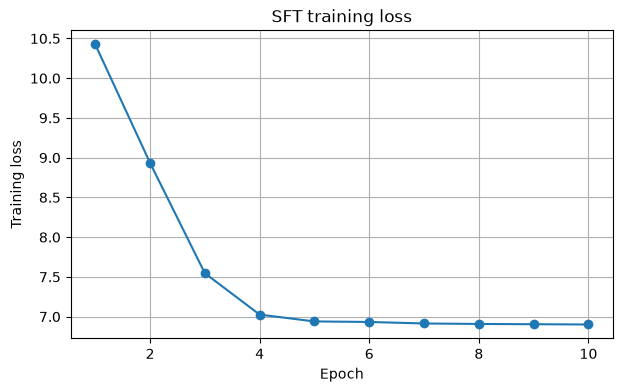

In [ ]:
epoch_numbers = []
losses = []

epoch_numbers = range(1, len(history["loss"]) + 1)
losses = history["loss"]

plt.figure(figsize=(7, 4))
plt.plot(epoch_numbers, losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("SFT training loss")
plt.grid(True)
plt.show()


## 10. Generate a few responses

In [ ]:
model.eval()

def generate_response(prompt, max_new_tokens=80):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
    ).to(device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
        )

    return tokenizer.decode(
        output[0],
        skip_special_tokens=False,
    )


test_prompts = [
    "What is the capital of France?\n\nResponse:",
    "Explain machine learning in one paragraph.\n\nResponse:",
    "Write a short Python function that adds two numbers.\n\nResponse:",
]

for prompt in test_prompts:
    print("=" * 80)
    print("PROMPT:")
    print(prompt)
    print("\nMODEL:")
    print(generate_response(prompt))


PROMPT:
What is the capital of France?

Response:

MODEL:
What is the capital of France?

Response:,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
PROMPT:
Explain machine learning in one paragraph.

Response:

MODEL:
Explain machine learning in one paragraph.

Response:,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
PROMPT:
Write a short Python function that adds two numbers.

Response:

MODEL:
Write a short Python function that adds two numbers.

Response:,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
